In [1]:
#imports
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import pandas as pd

TARGET_N = 5000
SEED = 42

df = pd.read_excel("train_binary.xlsx")

# Stratify
df_small = (
    df.groupby("label", group_keys=False)
      .apply(lambda x: x.sample(
          n=round(len(x) / len(df) * TARGET_N),
          random_state=SEED
      ))
      .reset_index(drop=True)
)

df_small = df_small.sample(frac=1, random_state=SEED).reset_index(drop=True)

output_path = f"train_binary_{TARGET_N}.xlsx"
df_small.to_excel(output_path, index=False)

print("Original distribution:")
print(df["label"].value_counts(normalize=True))

print("\nNew distribution:")
print(df_small["label"].value_counts(normalize=True))

print("\nSaved:", output_path)

Original distribution:
label
1    0.857636
0    0.142364
Name: proportion, dtype: float64

New distribution:
label
1    0.8576
0    0.1424
Name: proportion, dtype: float64

Saved: train_binary_5000.xlsx


C:\Users\Mohammad Pashaei\AppData\Local\Temp\ipykernel_19924\2699244713.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [3]:
from torchvision import transforms

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

train_tfms = transforms.Compose([
    #transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
   # transforms.RandomHorizontalFlip(0.5),
   # transforms.RandomVerticalFlip(0.5),
   # transforms.RandomRotation(15),
   # transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15, hue=0.02),
    transforms.Resize(256),
    #transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tfms = transforms.Compose([
    transforms.Resize(256),
    #transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

In [4]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset

class ISICBinaryDataset(Dataset):
    def __init__(self, df, images_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.images_dir = images_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def _resolve_path(self, image_id):
        base = os.path.join(self.images_dir, str(image_id))
        for ext in [".jpg"]:
            p = base + ext
            if os.path.isfile(p):
                return p
        if os.path.isfile(base):  
            return base
        raise FileNotFoundError(f"Image '{image_id}' not found in {self.images_dir}")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self._resolve_path(row["image"])
        y = int(row["label"])   # 0=MEL, 1=NV 

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(y, dtype=torch.long)

In [5]:
import pandas as pd

train_df = pd.read_excel("train_binary_1000.xlsx")
val_df   = pd.read_excel("val_binary.xlsx")
test_df  = pd.read_excel("test_binary.xlsx")

print(train_df.head())
print(val_df.head())
print(test_df.head())
print(train_df.shape, val_df.shape, test_df.shape)


          image  label
0  ISIC_0030588      1
1  ISIC_0025861      1
2  ISIC_0031555      1
3  ISIC_0031193      1
4  ISIC_0026658      1
          image  label
0  ISIC_0034321      1
1  ISIC_0034322      1
2  ISIC_0034324      1
3  ISIC_0034325      1
4  ISIC_0034328      1
          image  label
0  ISIC_0034524      1
1  ISIC_0034525      1
2  ISIC_0034527      1
3  ISIC_0034528      1
4  ISIC_0034529      0
(1000, 2) (144, 2) (1080, 2)


In [6]:
train_ds = ISICBinaryDataset(train_df, images_dir="train", transform=train_tfms)
val_ds   = ISICBinaryDataset(val_df,   images_dir="val",   transform=val_tfms)
test_ds  = ISICBinaryDataset(test_df,  images_dir="test",  transform=val_tfms)

In [7]:
x, y = train_ds[4]
print(x.shape, y.item())

torch.Size([3, 256, 341]) 1


In [8]:
import pandas as pd


def show_counts(df, name):
    counts = df["label"].value_counts().sort_index()
    mel = int(counts.get(0, 0))
    nv  = int(counts.get(1, 0))
    total = mel + nv
    print(f"\n{name}:")
    print(f"  MEL (0): {mel}  ({mel/total:.3f})")
    print(f"  NV  (1): {nv}   ({nv/total:.3f})")
    print(f"  Total : {total}")

show_counts(train_df, "TRAIN")
show_counts(val_df,   "VAL")
show_counts(test_df,  "TEST")


TRAIN:
  MEL (0): 142  (0.142)
  NV  (1): 858   (0.858)
  Total : 1000

VAL:
  MEL (0): 21  (0.146)
  NV  (1): 123   (0.854)
  Total : 144

TEST:
  MEL (0): 171  (0.158)
  NV  (1): 909   (0.842)
  Total : 1080


In [9]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,         
    num_workers=0,
    pin_memory=True
)

val_loader  = DataLoader(val_ds,  batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)

In [10]:
imgs, labels = next(iter(train_loader))
print(imgs.shape, labels[:])

torch.Size([8, 3, 256, 341]) tensor([1, 1, 1, 1, 1, 1, 1, 1])


[Batch, Channels, Height, Width]

In [11]:
imgs, labels = next(iter(test_loader))
print(imgs.shape, labels[:])

torch.Size([8, 3, 256, 341]) tensor([1, 1, 1, 1, 0, 1, 1, 1])


In [12]:
imgs, labels = next(iter(val_loader))
print(imgs.shape, labels[:])

torch.Size([8, 3, 256, 341]) tensor([1, 1, 1, 1, 1, 0, 1, 1])


In [13]:
#pre train resnet18
import torchvision.models as models
import torch.nn as nn
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#===========model============
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1) 
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 2)
model = model.to(device)



# Freeze 
for p in model.parameters():
    p.requires_grad = False

# Unfreeze fc
for p in model.fc.parameters():
    p.requires_grad = True

In [14]:
#freeze all layers and only train the final fc layer
"""
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
"""

'\nfor param in model.parameters():\n    param.requires_grad = True\n\noptimizer = torch.optim.Adam(model.parameters(), lr=1e-4)\n'

In [15]:
#leakage
train_ids = set(train_df["image"].astype(str))
val_ids   = set(val_df["image"].astype(str))
test_ids  = set(test_df["image"].astype(str))

print("train∩val :", len(train_ids & val_ids))
print("train∩test:", len(train_ids & test_ids))
print("val∩test  :", len(val_ids & test_ids))

train∩val : 0
train∩test: 0
val∩test  : 0


In [16]:
print("Trainable params:")
for n,p in model.named_parameters():
    if p.requires_grad:
        print(" ", n)

Trainable params:
  fc.weight
  fc.bias


Device: cuda
Epoch 01/15 | Train loss=0.5537 balAcc=0.679 | Val loss=0.3896 balAcc=0.827
Epoch 02/15 | Train loss=0.4345 balAcc=0.762 | Val loss=0.3577 balAcc=0.832
Epoch 03/15 | Train loss=0.4152 balAcc=0.784 | Val loss=0.3536 balAcc=0.836
Epoch 04/15 | Train loss=0.4000 balAcc=0.799 | Val loss=0.3873 balAcc=0.834
Epoch 05/15 | Train loss=0.3877 balAcc=0.811 | Val loss=0.3750 balAcc=0.785
Epoch 06/15 | Train loss=0.3689 balAcc=0.804 | Val loss=0.3363 balAcc=0.823
Epoch 07/15 | Train loss=0.3888 balAcc=0.799 | Val loss=0.3529 balAcc=0.864
Epoch 08/15 | Train loss=0.3479 balAcc=0.822 | Val loss=0.3386 balAcc=0.839
Epoch 09/15 | Train loss=0.3621 balAcc=0.849 | Val loss=0.3377 balAcc=0.844
Epoch 10/15 | Train loss=0.3537 balAcc=0.844 | Val loss=0.3282 balAcc=0.819
Epoch 11/15 | Train loss=0.3549 balAcc=0.827 | Val loss=0.3304 balAcc=0.852
Epoch 12/15 | Train loss=0.3306 balAcc=0.853 | Val loss=0.3267 balAcc=0.844
Epoch 13/15 | Train loss=0.3137 balAcc=0.864 | Val loss=0.3486 balAcc=0.856

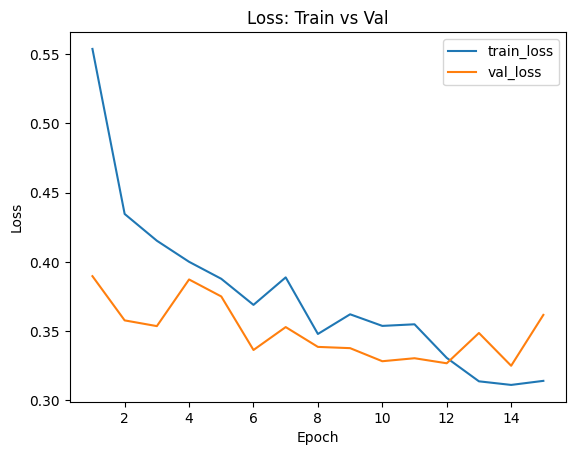

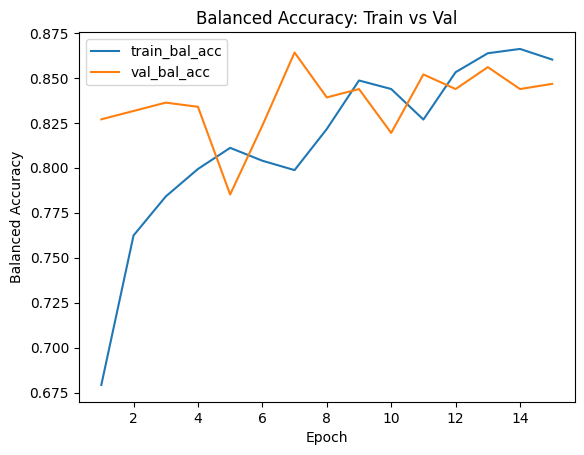

'\nrows = []\nfor h in history:\n    rows.append({\n        "epoch": h["epoch"],\n        "train_loss": h["train"]["loss"],\n        "train_bal_acc": h["train"]["bal_acc"],\n        "val_loss": h["val"]["loss"],\n        "val_bal_acc": h["val"]["bal_acc"],\n    })\ndf_hist = pd.DataFrame(rows)\ndf_hist.to_csv("history_balacc.csv", index=False)\nprint("Saved history to: history_balacc.csv")\n'

In [17]:
import copy
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models

from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    precision_recall_fscore_support,
    f1_score, balanced_accuracy_score,
    classification_report
)

# -----------------------
# Config
# -----------------------
EPOCHS = 15
LR = 1e-3
BEST_BY = "bal_acc"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# -----------------------
# Model: ResNet18 + head-only
# -----------------------
model.eval()        
model.fc.train()    

# -----------------------
# Loss + Optimizer
# -----------------------
#criterion = nn.CrossEntropyLoss()

#====weighted loss
import numpy as np
import torch

y_train = train_df["label"].values
class_counts = np.bincount(y_train, minlength=2)

w0 = 1.0 / max(class_counts[0], 1)  # MEL
w1 = 1.0 / max(class_counts[1], 1)  # NV

weights = torch.tensor([w0, w1], dtype=torch.float32).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=weights)
#========
optimizer = torch.optim.Adam(model.fc.parameters(), lr=LR)

# -----------------------
# Metric helpers
# -----------------------
from sklearn.metrics import balanced_accuracy_score
import numpy as np
import torch

def compute_metrics(y_true, y_pred):
    return {"bal_acc": balanced_accuracy_score(y_true, y_pred)}

@torch.no_grad()
def run_eval(model, loader):
    model.eval()
    total_loss = 0.0
    ys, ps = [], []

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = model(imgs)
        loss = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1)
        ys.append(labels.cpu().numpy())
        ps.append(preds.cpu().numpy())

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    m = compute_metrics(y_true, y_pred)
    m["loss"] = total_loss / len(loader.dataset)
    return m, y_true, y_pred

def run_train_one_epoch(model, loader):
    model.eval()        # BN ثابت
    model.fc.train()    # فقط head ترین

    total_loss = 0.0
    ys, ps = [], []

    for imgs, labels in loader:
        imgs = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)

        preds = torch.argmax(logits, dim=1)
        ys.append(labels.detach().cpu().numpy())
        ps.append(preds.detach().cpu().numpy())

    y_true = np.concatenate(ys)
    y_pred = np.concatenate(ps)
    m = compute_metrics(y_true, y_pred)
    m["loss"] = total_loss / len(loader.dataset)
    return m
# -----------------------
# Training loop
# -----------------------
history = []
best_score = -1.0
best_state = None
BEST_BY = "bal_acc"

for epoch in range(1, EPOCHS + 1):
    tr = run_train_one_epoch(model, train_loader)
    va, _, _ = run_eval(model, val_loader)

    history.append({"epoch": epoch, "train": tr, "val": va})

    print(
        f"Epoch {epoch:02d}/{EPOCHS} | "
        f"Train loss={tr['loss']:.4f} balAcc={tr['bal_acc']:.3f} | "
        f"Val loss={va['loss']:.4f} balAcc={va['bal_acc']:.3f}"
    )

    score = va[BEST_BY]
    if score > best_score:
        best_score = score
        best_state = copy.deepcopy(model.state_dict())

if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nLoaded best model by {BEST_BY} = {best_score:.4f}")

#==========
import pandas as pd
import matplotlib.pyplot as plt


save_path = "best_resnet18_headonly_balacc.pth"
if best_state is not None:
    torch.save(best_state, save_path)
    print("Saved best model weights to:", save_path)
else:
    # fallback: save current
    torch.save(model.state_dict(), save_path)
    print("Saved current model weights to:", save_path)

#==========
epochs = [h["epoch"] for h in history]

train_loss = [h["train"]["loss"] for h in history]
val_loss   = [h["val"]["loss"] for h in history]

train_bal  = [h["train"]["bal_acc"] for h in history]
val_bal    = [h["val"]["bal_acc"] for h in history]

#==========
plt.figure()
plt.plot(epochs, train_loss, label="train_loss")
plt.plot(epochs, val_loss, label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss: Train vs Val")
plt.legend()
plt.show()

#==========
plt.figure()
plt.plot(epochs, train_bal, label="train_bal_acc")
plt.plot(epochs, val_bal, label="val_bal_acc")
plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.title("Balanced Accuracy: Train vs Val")
plt.legend()
plt.show()

"""
rows = []
for h in history:
    rows.append({
        "epoch": h["epoch"],
        "train_loss": h["train"]["loss"],
        "train_bal_acc": h["train"]["bal_acc"],
        "val_loss": h["val"]["loss"],
        "val_bal_acc": h["val"]["bal_acc"],
    })
df_hist = pd.DataFrame(rows)
df_hist.to_csv("history_balacc.csv", index=False)
print("Saved history to: history_balacc.csv")
"""

In [ ]:
if best_state is not None:
    model.load_state_dict(best_state)
    print(f"\nLoaded best model by {BEST_BY} = {best_score:.4f}")


Loaded best model by bal_acc = 0.8641


In [19]:
# -----------------------
# Final Test 
# -----------------------
test_metrics, y_true, y_pred = run_eval(model, test_loader)

print("\nTEST RESULTS")
print(f"Test loss = {test_metrics['loss']:.4f}")
print(f"Test Balanced Accuracy = {test_metrics['bal_acc']:.4f}")


TEST RESULTS
Test loss = 0.4084
Test Balanced Accuracy = 0.7716


In [20]:
!jupyter nbconvert --to script Base_line_resnet18.ipynb

[NbConvertApp] Converting notebook Base_line_resnet18.ipynb to script
[NbConvertApp] Writing 11118 bytes to Base_line_resnet18.py
